<a href="https://colab.research.google.com/github/senujaBodhinayake/smart-medicine-availability-system/blob/develop/ai_notebooks_01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/AI Project/Datasets/global_pharmacy_sales_2020_2025_daily_dataset.csv')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

df = pd.read_csv(
    "global_pharmacy_sales_2020_2025_daily_dataset.csv",
    header=0,
    low_memory=False
)

print(df.head())
print(df.columns)

         date  year  month  day         region    country category  \
0  2025-10-12  2025     10   12    Middle East        UAE  Chronic   
1  2020-09-15  2020      9   15     South Asia      India  Chronic   
2  2020-02-26  2020      2   26    Middle East        UAE  Vitamin   
3  2025-11-09  2025     11    9     South Asia  Sri Lanka  Chronic   
4  2022-04-04  2022      4    4  South America  Argentina  Chronic   

     medicine age_group  units_sold  unit_price  stock_level  \
0  Amlodipine      0-12         328       45.38         4774   
1  Amlodipine     26-45         371       75.49         4584   
2   Vitamin C      0-12         948       22.51         3934   
3  Amlodipine      0-12         275       63.29         4544   
4  Amlodipine     26-45         563       44.28         4284   

   expiry_days_remaining  covid_flag  
0                    466           0  
1                    181           1  
2                    556           1  
3                    330           0  

In [ ]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(177990, 14)
Index(['date', 'year', 'month', 'day', 'region', 'country', 'category',
       'medicine', 'age_group', 'units_sold', 'unit_price', 'stock_level',
       'expiry_days_remaining', 'covid_flag'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177990 entries, 0 to 177989
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   date                   177990 non-null  object 
 1   year                   177990 non-null  int64  
 2   month                  177990 non-null  int64  
 3   day                    177990 non-null  int64  
 4   region                 177990 non-null  object 
 5   country                177990 non-null  object 
 6   category               177990 non-null  object 
 7   medicine               177990 non-null  object 
 8   age_group              177990 non-null  object 
 9   units_sold             177990 non-null  int64  
 10  unit_price         

In [ ]:
df.isnull().sum()

,0
date,0
year,0
month,0
day,0
region,0
country,0
category,0
medicine,0
age_group,0
units_sold,0


In [ ]:
df.duplicated().sum()

np.int64(2630)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df['date'].dtype

dtype('<M8[ns]')

In [ ]:
df = df.sort_values("date")

In [ ]:
Q1 = df['units_sold'].quantile(0.25)
Q3 = df['units_sold'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Outlier bounds: {lower:.1f} to {upper:.1f}")

df['units_sold'] = df['units_sold'].clip(lower=lower, upper=upper)

df = df[df['units_sold'] >= 0].reset_index(drop=True)

Outlier bounds: -82.0 to 894.0


Aggregate Daily Demand

In [ ]:
daily_sales = df.groupby('date')['units_sold'].sum().reset_index()

daily_sales.head()

,date,units_sold
0,2020-01-01,53314
1,2020-01-02,54682
2,2020-01-03,52887
3,2020-01-04,51400
4,2020-01-05,52716


Create Time Features

In [ ]:
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['year'] = daily_sales['date'].dt.year

Create Lag Features

In [ ]:
daily_sales['lag_1'] = daily_sales['units_sold'].shift(1)
daily_sales['lag_7'] = daily_sales['units_sold'].shift(7)
daily_sales['lag_30'] = daily_sales['units_sold'].shift(30)

Create moving Averages

In [ ]:
daily_sales['rolling_7'] = (
    daily_sales['units_sold']
    .rolling(window=7)
    .mean()
)

daily_sales['rolling_30'] = (
    daily_sales['units_sold']
    .rolling(window=30)
    .mean()
)

Remove Null Values
Lag and rolling features create empty rows.

In [ ]:
daily_sales.dropna(inplace=True)

daily_sales.reset_index(drop=True, inplace=True)

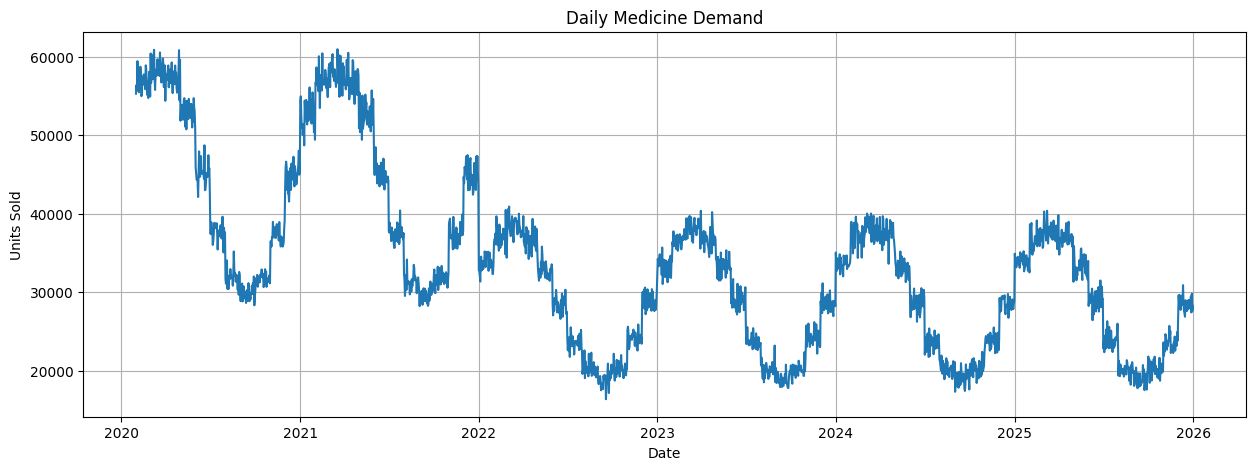

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(
    daily_sales['date'],
    daily_sales['units_sold']
)

plt.title("Daily Medicine Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.grid(True)

plt.show()

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
daily_sales.to_csv(
    "/content/drive/MyDrive/AI Project/Datasets/Processed Data/processed_sales.csv",
    index=False
)

In [ ]:
daily_sales.head()
daily_sales.shape
daily_sales.columns

Index(['date', 'units_sold', 'day_of_week', 'month', 'year', 'lag_1', 'lag_7',
       'lag_30', 'rolling_7', 'rolling_30'],
      dtype='object')